In [104]:
import pandas as pd

In [105]:
df=pd.read_csv(r"C:\Users\adity\Desktop\Tekworks\Week-10\Day-19\knn_regression_dataset.csv")
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [106]:
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


In [107]:
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [108]:
df['income']=df['income'].fillna(df['income'].median())
df['loan_amount']=df['loan_amount'].fillna(df['loan_amount'].median())
df['credit_score']=df['credit_score'].fillna(df['credit_score'].median())

In [109]:
df.isnull().sum()

age                0
income             0
loan_amount        0
credit_score       0
city               0
employment_type    0
target             0
dtype: int64

In [110]:
import matplotlib.pyplot as plt
import seaborn as sns

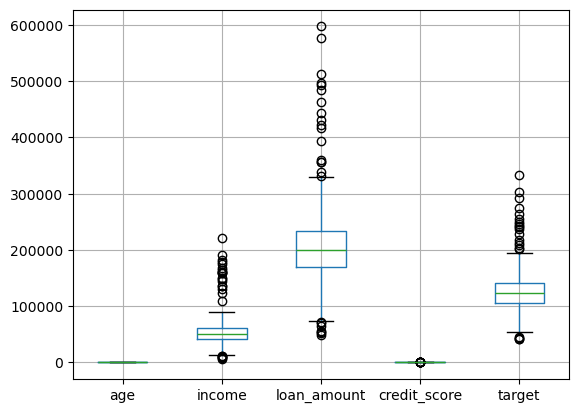

In [111]:
df.boxplot()
plt.show()

In [112]:
# use the clip method to cap the outliers in income column
def cap_outliers(column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    return df[column].clip(lower_bound, upper_bound)

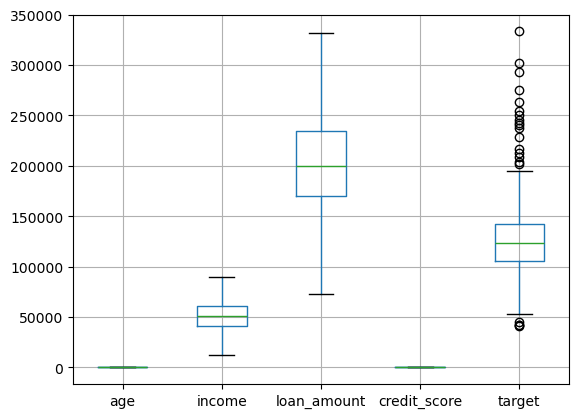

In [113]:
df['income']=cap_outliers('income')
df['loan_amount']=cap_outliers('loan_amount')
df['credit_score']=cap_outliers('credit_score')
df.boxplot()
plt.show()

In [114]:
df['city'].unique()

array(['Chennai', 'Hyderabad', 'Bangalore', 'Mumbai'], dtype=object)

In [115]:
df['employment_type'].unique()

array(['Salaried', 'Unemployed', 'Self-Employed'], dtype=object)

In [116]:
df=pd.get_dummies(df,columns=['city'])
df.head()

,age,income,loan_amount,credit_score,employment_type,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai
0,56,25903.305196,286348.192562,789.476075,Salaried,158793.631698,False,True,False,False
1,69,53051.954538,180018.190719,596.334039,Salaried,115596.093965,False,True,False,False
2,46,38654.738821,211234.236288,611.531000,Salaried,127231.057638,False,True,False,False
3,32,28666.194356,246629.541594,710.171152,Unemployed,145102.187078,False,True,False,False
4,60,40301.406736,129081.713353,622.900855,Unemployed,110623.128404,False,False,True,False


In [117]:
df=pd.get_dummies(df,columns=['employment_type'])
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,False,True,False,False,True,False,False
1,69,53051.954538,180018.190719,596.334039,115596.093965,False,True,False,False,True,False,False
2,46,38654.738821,211234.236288,611.531000,127231.057638,False,True,False,False,True,False,False
3,32,28666.194356,246629.541594,710.171152,145102.187078,False,True,False,False,False,False,True
4,60,40301.406736,129081.713353,622.900855,110623.128404,False,False,True,False,False,False,True


In [118]:
df['city_Bangalore']=df['city_Bangalore'].replace([False,True],[0,1])
df['city_Hyderabad']=df['city_Hyderabad'].replace([False,True],[0,1])
df['city_Mumbai']=df['city_Mumbai'].replace([False,True],[0,1])
df['city_Chennai']=df['city_Chennai'].replace([False,True],[0,1])

C:\Users\adity\AppData\Local\Temp\ipykernel_17796\923731148.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['city_Bangalore']=df['city_Bangalore'].replace([False,True],[0,1])
C:\Users\adity\AppData\Local\Temp\ipykernel_17796\923731148.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['city_Hyderabad']=df['city_Hyderabad'].replace([False,True],[0,1])
C:\Users\adity\AppData\Local\Temp\ipykernel_17796\923731148.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To

In [119]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0,1,0,0,True,False,False
1,69,53051.954538,180018.190719,596.334039,115596.093965,0,1,0,0,True,False,False
2,46,38654.738821,211234.236288,611.531000,127231.057638,0,1,0,0,True,False,False
3,32,28666.194356,246629.541594,710.171152,145102.187078,0,1,0,0,False,False,True
4,60,40301.406736,129081.713353,622.900855,110623.128404,0,0,1,0,False,False,True


In [120]:
df['employment_type_Salaried']=df['employment_type_Salaried'].replace([False,True],[0,1])
df['employment_type_Self-Employed']=df['employment_type_Self-Employed'].replace([False,True],[0,1])
df['employment_type_Unemployed']=df['employment_type_Unemployed'].replace([False,True],[0,1])

C:\Users\adity\AppData\Local\Temp\ipykernel_17796\3655029977.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['employment_type_Salaried']=df['employment_type_Salaried'].replace([False,True],[0,1])
C:\Users\adity\AppData\Local\Temp\ipykernel_17796\3655029977.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['employment_type_Self-Employed']=df['employment_type_Self-Employed'].replace([False,True],[0,1])
C:\Users\adity\AppData\Local\Temp\ipykernel_17796\3655029977.py:3: FutureWarning: Downcasting behavior in `replace` is d

In [121]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0,1,0,0,1,0,0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0,1,0,0,1,0,0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0,1,0,0,1,0,0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0,1,0,0,0,0,1
4,60,40301.406736,129081.713353,622.900855,110623.128404,0,0,1,0,0,0,1


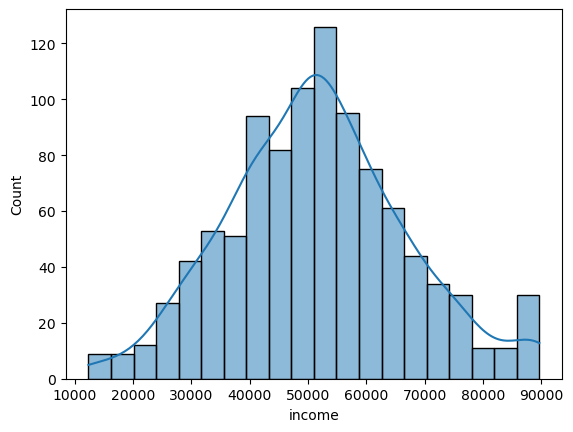

In [125]:
sns.histplot(df['income'],kde=True)
plt.show()

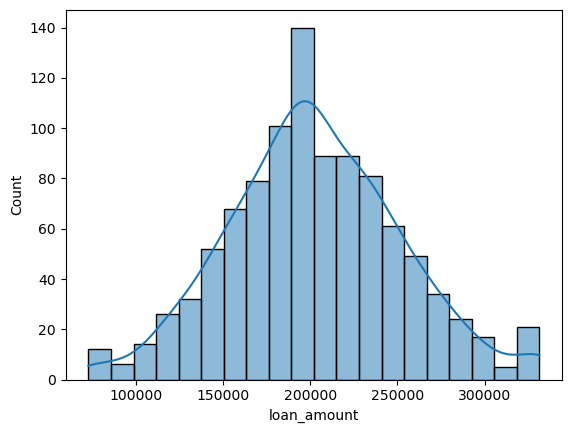

In [126]:
sns.histplot(df['loan_amount'],kde=True)
plt.show()

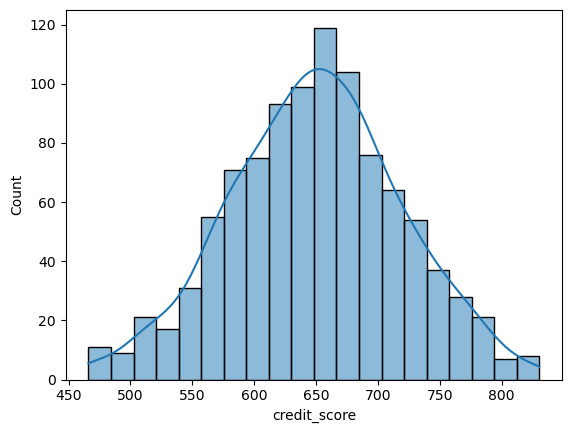

In [127]:
sns.histplot(df['credit_score'],kde=True)
plt.show()

In [ ]:
# normal_skewed_features = skewness[skewness == 0].index.tolist()
# positive_skewed_features = skewness[skewness > 0].index.tolist()
# negative_skewed_features = skewness[skewness < 0].index.tolist()
 
# print("Normal skewed features: ", normal_skewed_features)
# print("Positive skewed features: ", positive_skewed_features)
# print("Negative skewed features: ", negative_skewed_features)

In [130]:
from sklearn.preprocessing import MinMaxScaler
normal_skew = ['income','loan_amount']
scaler = MinMaxScaler()
df[normal_skew] = scaler.fit_transform(df[normal_skew])
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,2.013602,158793.631698,0,1,0,0,1,0,0
1,69,0.526493,0.414927,-0.763656,115596.093965,0,1,0,0,1,0,0
2,46,0.340377,0.535516,-0.545133,127231.057638,0,1,0,0,1,0,0
3,32,0.211253,0.672249,0.873248,145102.187078,0,1,0,0,0,0,1
4,60,0.361664,0.218158,-0.381642,110623.128404,0,0,1,0,0,0,1


In [131]:
from sklearn.preprocessing import StandardScaler
normal_skew = ['credit_score']
scaler = StandardScaler()
df[normal_skew] = scaler.fit_transform(df[normal_skew])
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,2.013602,158793.631698,0,1,0,0,1,0,0
1,69,0.526493,0.414927,-0.763656,115596.093965,0,1,0,0,1,0,0
2,46,0.340377,0.535516,-0.545133,127231.057638,0,1,0,0,1,0,0
3,32,0.211253,0.672249,0.873248,145102.187078,0,1,0,0,0,0,1
4,60,0.361664,0.218158,-0.381642,110623.128404,0,0,1,0,0,0,1


In [132]:
x=df.drop('target',axis=1)
y=df['target']

In [133]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [134]:
x_train

,age,income,loan_amount,credit_score,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
29,42,0.477299,0.454712,0.558878,0,0,1,0,0,1,0
535,22,0.393211,0.105068,-2.636124,0,0,0,1,0,1,0
695,65,0.467971,0.527801,-0.496663,1,0,0,0,0,1,0
557,29,0.690081,0.150418,-0.199940,1,0,0,0,1,0,0
836,54,0.368851,0.384281,1.137237,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
106,18,0.648049,0.332267,-0.797257,1,0,0,0,1,0,0
270,24,0.297810,0.365782,-0.460833,1,0,0,0,1,0,0
860,51,0.571766,0.587152,-1.025071,0,1,0,0,1,0,0
435,63,0.523225,0.372200,0.681064,0,1,0,0,0,0,1


In [135]:
x_test

,age,income,loan_amount,credit_score,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
521,22,0.361594,0.432634,1.908087,0,0,1,0,1,0,0
737,49,0.903002,0.444404,0.734234,1,0,0,0,0,1,0
740,38,0.609935,0.635860,1.387546,0,1,0,0,0,1,0
660,56,0.457943,0.525599,-0.091718,0,1,0,0,0,0,1
411,59,0.713776,0.470946,0.224834,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
408,40,0.646138,0.597633,0.150209,0,0,0,1,0,1,0
332,58,0.687123,0.440251,1.852595,0,0,0,1,0,0,1
208,61,0.417046,0.605439,-1.015321,1,0,0,0,1,0,0
613,66,0.471389,0.477484,1.295877,1,0,0,0,0,0,1


In [136]:
y_train

29     120225.912489
535     61977.952624
695    124527.161195
557     76225.586596
836     97217.947007
           ...      
106    123432.668599
270     99654.806469
860    154444.353604
435    125160.818016
102    122326.980938
Name: target, Length: 800, dtype: float64

In [137]:
y_test

521    110471.776903
737    121748.553871
740    132938.442373
660    115222.901825
411    127576.987078
           ...      
408    141794.447930
332    132256.319908
208    134245.338603
613    128693.737524
78     126448.010486
Name: target, Length: 200, dtype: float64

In [141]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor(n_neighbors=5)
knn.fit(x_train,y_train)

KNeighborsRegressor()

In [142]:
y_pred=knn.predict(x_test)

In [145]:
from sklearn.metrics import mean_squared_error,r2_score
print("Mean Squared Error: ",mean_squared_error(y_test,y_pred))
print("R2 Score: ",r2_score(y_test,y_pred))

Mean Squared Error:  1150544257.404101
R2 Score:  -0.10279143852101558


In [153]:
mse_values=[]
k_values=range(1,21)
for k in k_values:
    knn=KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    mse_values.append(mean_squared_error(y_test,y_pred))

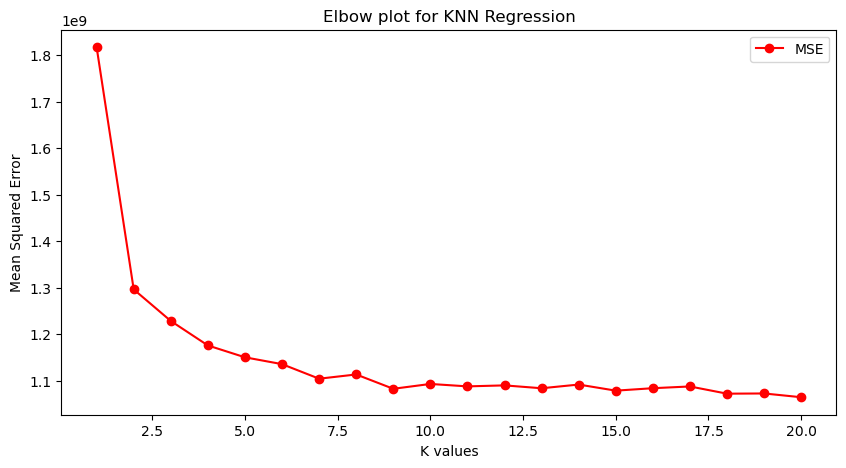

In [155]:
plt.figure(figsize=(10,5))
plt.plot(k_values,mse_values,marker="o",color='red',label='MSE')
plt.title("Elbow plot for KNN Regression")
plt.xlabel("K values")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

In [156]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("Mean Squared Error: ",mean_squared_error(y_test,y_pred))
print("R2 Score: ",r2_score(y_test,y_pred))

Mean Squared Error:  204308498.00808188
R2 Score:  0.8041712337700486


In [166]:
# testing for decision tree regression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Decision Tree Regression
dt = DecisionTreeRegressor()
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree Mean Squared Error: ", mse_dt)
print("Decision Tree R2 Score: ", r2_dt)

Decision Tree Mean Squared Error:  536456093.12757033
Decision Tree R2 Score:  0.4858092743183088
